# **Homework 3**

**Name:** Ankit BhagwatiPrasad Dhandharia

**CWID:** 20033031

**Assignment Number & Name:** HW03_KNN

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## **1. Load the “breast-cancer-wisconsin.data.csv” into Python**

In [31]:
# Loading the dataset
features_domain = [
    'Sample code number', 'Clump Thickness', 'Uniformity of Cell Size','Uniformity of Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
    'Normal Nucleoli', 'Mitoses', 'Class']
df = pd.read_csv('drive/MyDrive/breast-cancer-wisconsin.csv',header=0,names=features_domain)
df.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [32]:
df.isnull().sum()

,0
Sample code number,0
Clump Thickness,0
Uniformity of Cell Size,0
Uniformity of Cell Shape,0
Marginal Adhesion,0
Single Epithelial Cell Size,0
Bare Nuclei,0
Bland Chromatin,0
Normal Nucleoli,0
Mitoses,0


In [34]:
df.replace('?', np.nan, inplace=True)
original_count = df.shape[0]
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
feature_cols = df.columns[1:-1]  # All features except ID and Class
df[feature_cols] = df[feature_cols].apply(pd.to_numeric)
df[feature_cols].describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [35]:
# Map class values 2 for benign, 4 for malignant to binary 0 and 1
df['Class_Binary'] = df['Class'].map({2: 0, 4: 1})

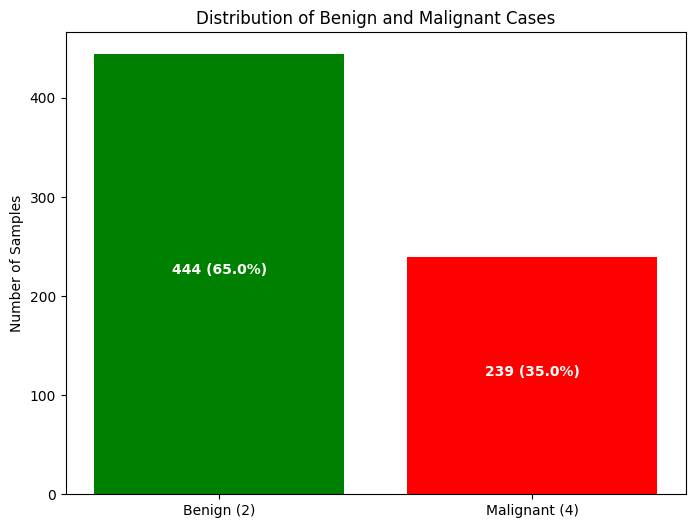

In [36]:
# Class distribution visualization
plt.figure(figsize=(8, 6))
diagnosis_dist = df['Class'].value_counts().sort_index()
plt.bar(['Benign (2)', 'Malignant (4)'], [diagnosis_dist[2], diagnosis_dist[4]], color=['green', 'red'])
plt.title('Distribution of Benign and Malignant Cases')
plt.ylabel('Number of Samples')
plt.text(0, diagnosis_dist[2]/2, f"{diagnosis_dist[2]} ({diagnosis_dist[2]/df.shape[0]:.1%})",
         ha='center', color='white', fontweight='bold')
plt.text(1, diagnosis_dist[4]/2, f"{diagnosis_dist[4]} ({diagnosis_dist[4]/df.shape[0]:.1%})",
         ha='center', color='white', fontweight='bold')
plt.show()

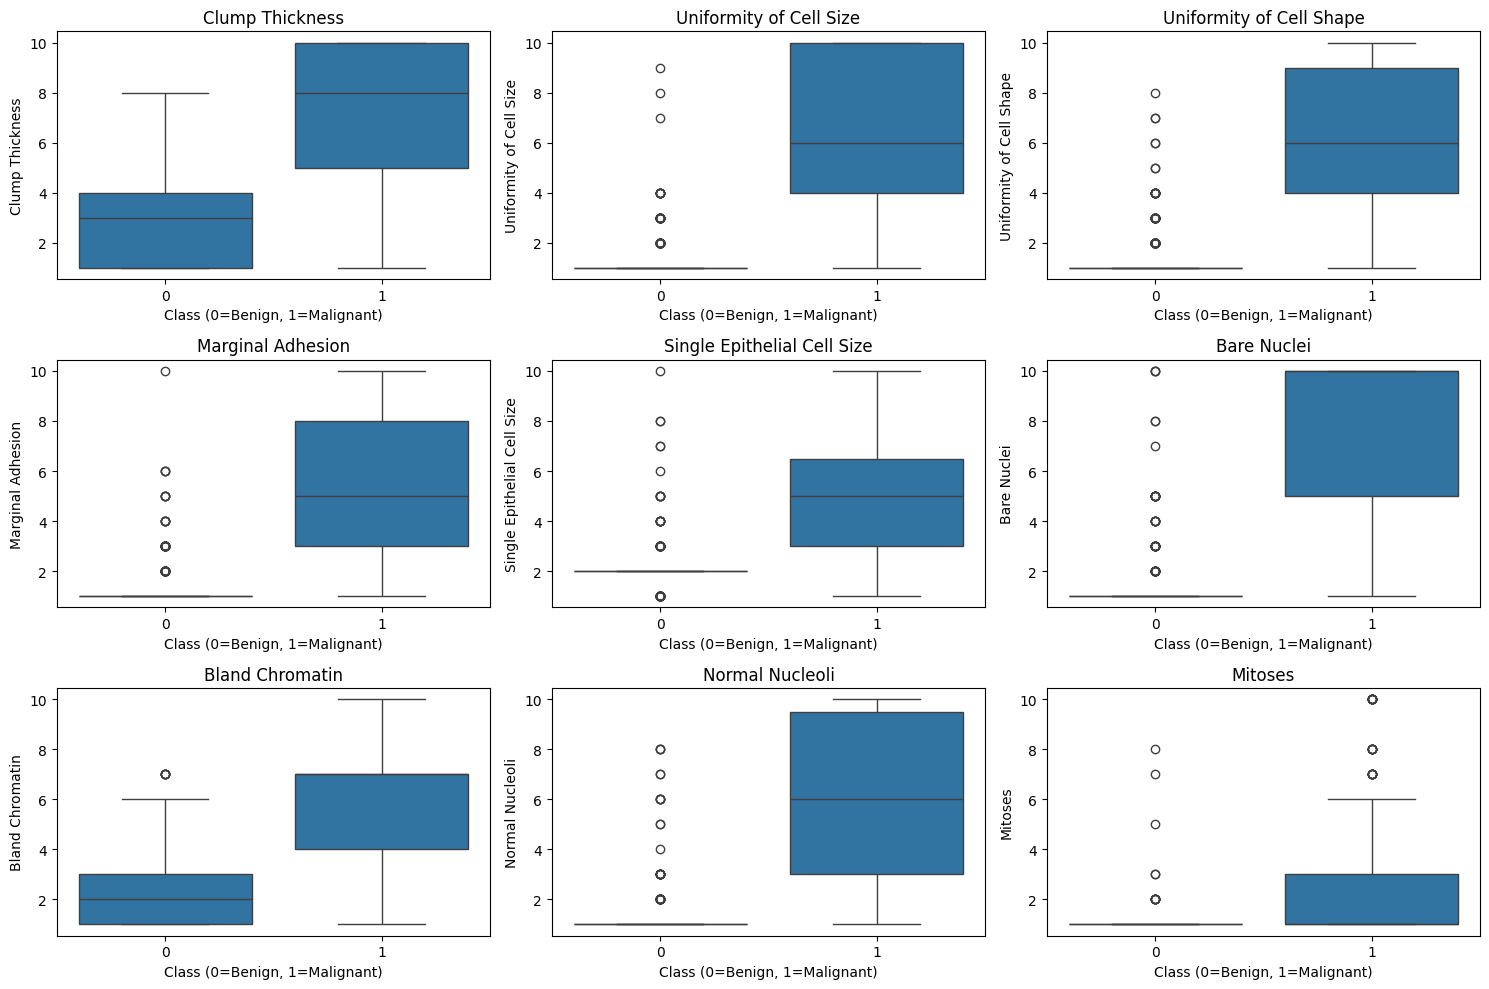

In [38]:
# Visualize feature distributions by class
plt.figure(figsize=(15, 10))
for i, feature in enumerate(feature_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Class_Binary', y=feature, data=df)
    plt.title(feature)
    plt.xlabel('Class (0=Benign, 1=Malignant)')
plt.tight_layout()
plt.show()

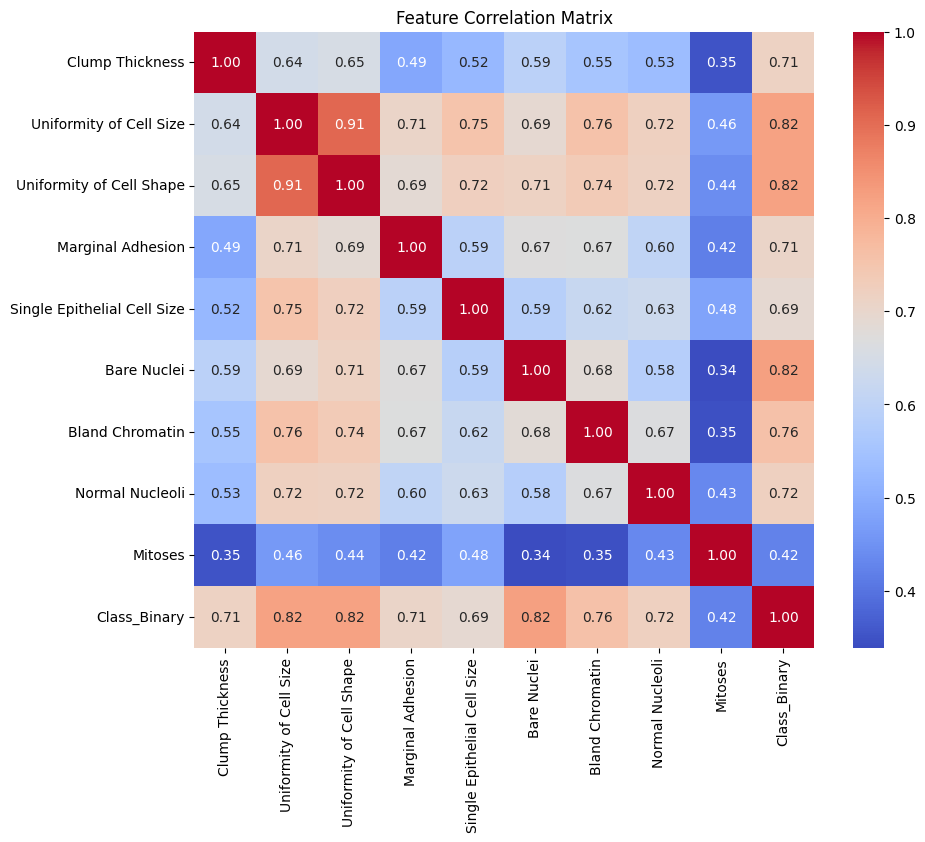

In [39]:
# Correlation matrix to understand feature relationships
plt.figure(figsize=(10, 8))
correlation = df[list(feature_cols) + ['Class_Binary']].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [40]:
# Insights from correlation matrix
correlated_pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        corr_value = correlation.iloc[i, j]
        if abs(corr_value) > 0.7:  # Threshold for high correlation
            correlated_pairs.append((feature_cols[i], feature_cols[j], corr_value))

In [41]:
for f1, f2, corr in correlated_pairs:
    print(f"{f1} and {f2}: {corr:.2f}")

Uniformity of Cell Size and Uniformity of Cell Shape: 0.91
Uniformity of Cell Size and Marginal Adhesion: 0.71
Uniformity of Cell Size and Single Epithelial Cell Size: 0.75
Uniformity of Cell Size and Bland Chromatin: 0.76
Uniformity of Cell Size and Normal Nucleoli: 0.72
Uniformity of Cell Shape and Single Epithelial Cell Size: 0.72
Uniformity of Cell Shape and Bare Nuclei: 0.71
Uniformity of Cell Shape and Bland Chromatin: 0.74
Uniformity of Cell Shape and Normal Nucleoli: 0.72


In [43]:
# Identify features with highest correlation to Class
class_corr = correlation['Class_Binary'].drop('Class_Binary').sort_values(ascending=False)
print("Features most correlated with Class (malignancy):")
for feature, corr in class_corr.items():
    print(f"{feature}: {corr:.2f}")

Features most correlated with Class (malignancy):
Bare Nuclei: 0.82
Uniformity of Cell Shape: 0.82
Uniformity of Cell Size: 0.82
Bland Chromatin: 0.76
Normal Nucleoli: 0.72
Clump Thickness: 0.71
Marginal Adhesion: 0.71
Single Epithelial Cell Size: 0.69
Mitoses: 0.42


In [44]:
X_features = df[feature_cols]  # Features
y_target = df['Class']  # Target (original class values: 2, 4)

# Split data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=42)

In [45]:
# Feature scaling is important for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
def evaluate_knn_model(k_value, X_train_data, X_test_data, y_train_data, y_test_data):
    """Train and evaluate KNN model with specified k value"""
    # Create and train model
    knn_classifier = KNeighborsClassifier(n_neighbors=k_value)
    knn_classifier.fit(X_train_data, y_train_data)

    # Make predictions
    y_pred = knn_classifier.predict(X_test_data)

    # Calculate accuracy
    acc = accuracy_score(y_test_data, y_pred)

    # Generate confusion matrix
    cm = confusion_matrix(y_test_data, y_pred)

    # Generate classification report
    report = classification_report(y_test_data, y_pred, target_names=['Benign (2)', 'Malignant (4)'])

    # Print results
    print(f"Results for k={k_value}:")
    print(f"Accuracy: {acc:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    # Visualize confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['Benign (2)', 'Malignant (4)'],
               yticklabels=['Benign (2)', 'Malignant (4)'])
    plt.title(f'Confusion Matrix (k={k_value})')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

    # Calculate additional metrics from confusion matrix
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)  # True positive rate (recall)
    specificity = tn / (tn + fp)  # True negative rate
    precision = tp / (tp + fp)    # Positive predictive value

    print(f"Sensitivity (TPR): {sensitivity:.4f}")
    print(f"Specificity (TNR): {specificity:.4f}")
    print(f"Precision (PPV): {precision:.4f}")

    print("\nClassification Report:")
    print(report)

    return acc, sensitivity, specificity, precision

Results for k=3:
Accuracy: 0.9561

Confusion Matrix:
[[125   2]
 [  7  71]]


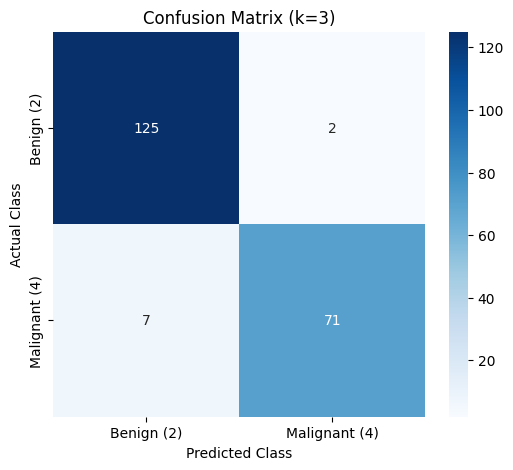

Sensitivity (TPR): 0.9103
Specificity (TNR): 0.9843
Precision (PPV): 0.9726

Classification Report:
               precision    recall  f1-score   support

   Benign (2)       0.95      0.98      0.97       127
Malignant (4)       0.97      0.91      0.94        78

     accuracy                           0.96       205
    macro avg       0.96      0.95      0.95       205
 weighted avg       0.96      0.96      0.96       205

Results for k=5:
Accuracy: 0.9610

Confusion Matrix:
[[125   2]
 [  6  72]]


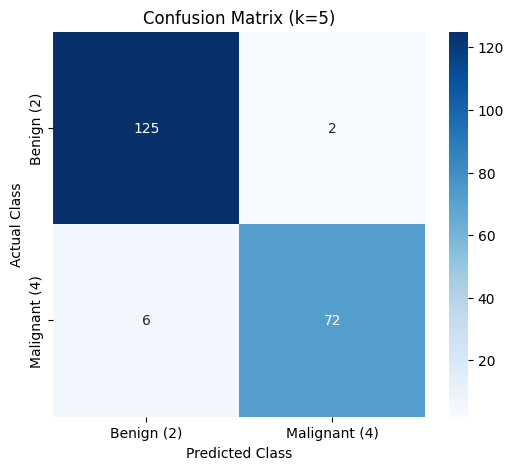

Sensitivity (TPR): 0.9231
Specificity (TNR): 0.9843
Precision (PPV): 0.9730

Classification Report:
               precision    recall  f1-score   support

   Benign (2)       0.95      0.98      0.97       127
Malignant (4)       0.97      0.92      0.95        78

     accuracy                           0.96       205
    macro avg       0.96      0.95      0.96       205
 weighted avg       0.96      0.96      0.96       205

Results for k=10:
Accuracy: 0.9512

Confusion Matrix:
[[125   2]
 [  8  70]]


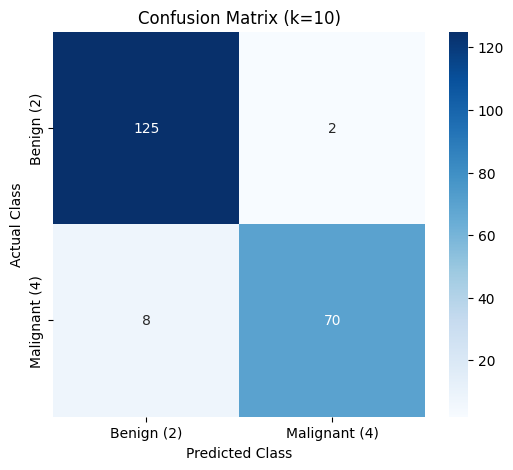

Sensitivity (TPR): 0.8974
Specificity (TNR): 0.9843
Precision (PPV): 0.9722

Classification Report:
               precision    recall  f1-score   support

   Benign (2)       0.94      0.98      0.96       127
Malignant (4)       0.97      0.90      0.93        78

     accuracy                           0.95       205
    macro avg       0.96      0.94      0.95       205
 weighted avg       0.95      0.95      0.95       205



In [48]:
k_values = [3, 5, 10]
results_dict = {}
for k in k_values:
    accuracy, sensitivity, specificity, precision = evaluate_knn_model(k, X_train_scaled, X_test_scaled, y_train, y_test)
    results_dict[k] = {
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision
    }

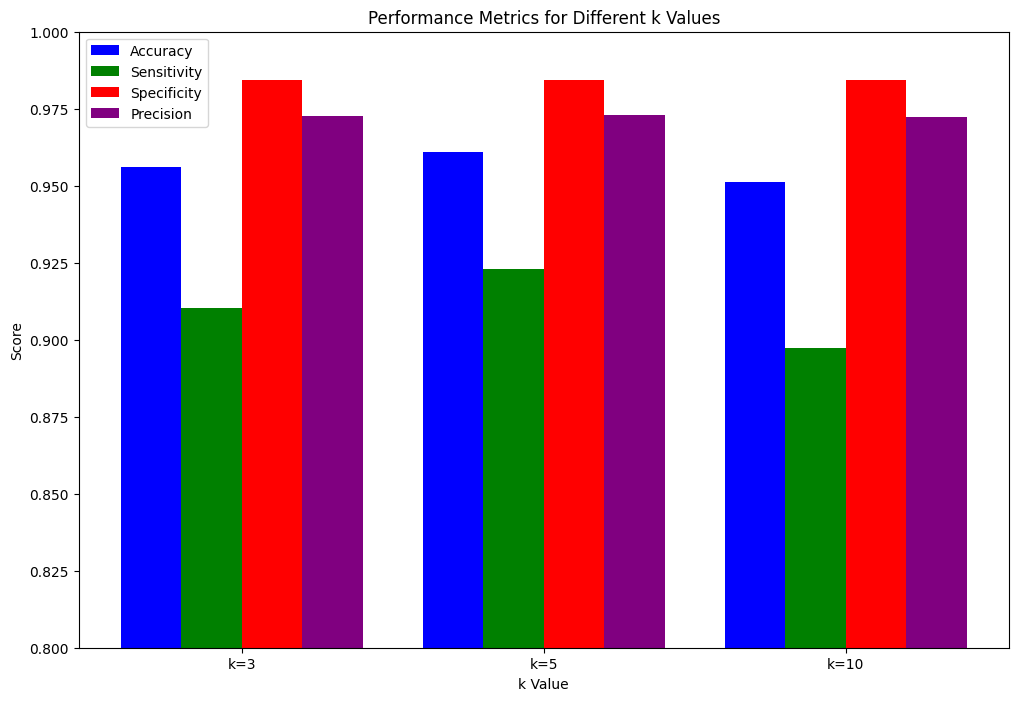

In [51]:
# Compare model performance across k values
metric_names = ['accuracy', 'sensitivity', 'specificity', 'precision']
metric_values = {metric: [results_dict[k][metric] for k in k_values] for metric in metric_names}

# Visualize comparison of different metrics across k values
plt.figure(figsize=(12, 8))
bar_width = 0.2
index1 = np.arange(len(k_values))
index2 = [x + bar_width for x in index1]
index3 = [x + bar_width for x in index2]
index4 = [x + bar_width for x in index3]

plt.bar(index1, metric_values['accuracy'], width=bar_width, label='Accuracy', color='blue')
plt.bar(index2, metric_values['sensitivity'], width=bar_width, label='Sensitivity', color='green')
plt.bar(index3, metric_values['specificity'], width=bar_width, label='Specificity', color='red')
plt.bar(index4, metric_values['precision'], width=bar_width, label='Precision', color='purple')

plt.xlabel('k Value')
plt.ylabel('Score')
plt.title('Performance Metrics for Different k Values')
plt.xticks([r + bar_width for r in range(len(k_values))], [f'k={k}' for k in k_values])
plt.legend()
plt.ylim(0.8, 1.0)  # Adjust as needed based on your results
plt.show()

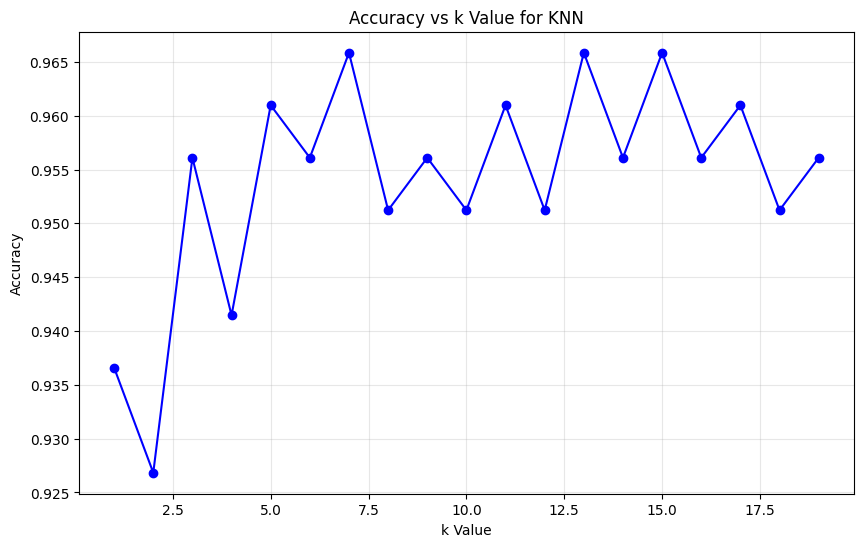

In [54]:
k_range = range(1, 20)  # Odd values from 1 to 19
k_accuracy_list = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    k_accuracy_list.append(accuracy_score(y_test, y_pred))

# Plot accuracies for different k values
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_accuracy_list, marker='o', linestyle='-', color='blue')
plt.xlabel('k Value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs k Value for KNN')
plt.grid(True, alpha=0.3)

# Highlight the best k
optimal_k = k_range[np.argmax(k_accuracy_list)]
plt.show()

In [55]:
print(f"Optimal k value from wider analysis: {optimal_k}")

Optimal k value from wider analysis: 7
